# Prognostisering av besöksvolym på akutmottagningen med exponentiell utjämning (PROC ESM)


## Sammanfattning

Ett medelstort sjukhussystem behöver en prognos ett år framåt för den månatliga besöksvolymen på akutmottagningen (ED) för att planera sjuksköterskebemanning och sängkapacitet inför vinterns luftvägstopp. Denna notebook bygger en syntetisk fyraårig månatlig ED-census (48 månader, jan 2021 - dec 2024) och anpassar en multiplikativ säsongsmodell av Winters-typ med **PROC ESM** för att ta fram en 12-månadersprognos med 95 % prediktionsintervall.

Den anpassade modellen fångar serien väl: **RMSE inom stickprovet är cirka 320 besök** och **MAPE är 4,16 %**, så det typiska månatliga felet ligger under 5 % av volymen. Prognosen projicerar den välbekanta säsongsformen in i 2025 - en topp i december-februari nära **7 300-7 800 besök/månad** och en dal i sensommaren nära **5 800-5 900** - med prediktionsband som breddas i takt med att horisonten sträcks ut. Dessa siffror, och utjämningsvikterna bakom dem, avläses direkt från procedurens utdataset nedan.


## Datakällor

| Dataset | Rader | Granularitet | Nyckelvariabler | Beskrivning |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | En rad per kalendermånad, jan 2021 - dec 2024 | `month` (månatligt SAS-datum), `ed_visits` (heltal, månatligt antal ED-besök) | Syntetisk månatlig besöksvolym på akutmottagningen för ett medelstort sjukhussystem. Genererad med en uppåtriktad tillväxttrend (~3 % per år), en multiplikativ säsongscykel som toppar under vinterns luftvägssäsong (dec-feb) och sjunker under sensommaren, plus log-normalt brus så att säsongsamplituden skalar med den stigande nivån. |


# Prognostisering av besöksvolym på akutmottagningen med PROC ESM

Kapacitetsplanerare behöver veta hur många ED-besök som kan förväntas varje månad så att de kan schemalägga sjuksköterskor, hålla flexsängar tillgängliga och förbereda luftvägsförnödenheter inför vintertoppen. ED-volymen är en läroboksexempel på en säsongsbetonad tidsserie: den växer långsamt år för år, toppar under luftvägssäsongen december-februari och ebbar ut i sensommaren, och storleken på säsongssvängningen växer i takt med att grundvolymen växer. Denna multiplikativa säsongsstruktur är precis vad den multiplikativa Winters-metoden i **PROC ESM** är utformad för att fånga.

I denna notebook gör vi följande:

1. Genererar en realistisk fyraårig månatlig ED-census med trend, multiplikativ säsongsvariation och brus.
2. Visualiserar serien för att bekräfta dess multiplikativa säsongsstruktur.
3. Anpassar en multiplikativ Winters-modell med PROC ESM och avläser dess utjämningsvikter och anpassningsstatistik från utdataseten.
4. Tar fram en prognos 12 månader framåt med 95 % prediktionsintervall och tolkar de operativa konsekvenserna.


## Steg 1 - Generera den syntetiska månatliga ED-censusen

Vi bygger 48 månatliga observationer från januari 2021 till december 2024. Varje månads förväntade volym är en grundnivå som växer cirka 3 % per år, multiplicerad med ett säsongsindex (högst mitt i vintern, lägst i sensommaren), och därefter störd av log-normalt brus så att den slumpmässiga variationen skalar med nivån. `intnx` flyttar fram det månadsjusterade datumet en period per rad, och `streaminit` gör dragningen reproducerbar.


In [1]:
data ed_census;
    CALL streaminit(20240531);
    /* Monthly seasonal index: peaks Dec-Feb (flu/RSV), troughs Aug-Sep */
    FÄLT seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    format month yymmn6.;
    GÖR i = 1 TILL 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Baseline ~6000 visits/mo growing ~3% per year */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Multiplicative seasonality + level-scaled lognormal noise */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        UTDATA;
    SLUT;
    BEHÅLL month ed_visits;
KÖR;

PROCEDUR SKRIV data=ed_census(obs=14) noobs ETIKETT;
    ETIKETT month = "Månad" ed_visits = "Akutbesök";
    TITEL "Första 14 månaderna av syntetisk akutbesöksvolym";
KÖR;


                                    Första 14 månaderna av syntetisk akutbesöksvolym                                    

 Månad   Akutbesök
202101        7103
202102        6835
202103        6668
202104        5611
202105        5816
202106        5383
202107        5586
202108        5283
202109        5161
202110        6109
202111        6451
202112        6730
202201        6847
202202        7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


De första månaderna bekräftar designen: volymen öppnar nära 7 100 i januaritoppen 2021, faller genom våren och sommaren till sin dal i augusti-september och klättrar sedan tillbaka in i nästa vinter. Vid januari 2022 har toppen krupit upp till cirka 6 800-7 200, vilket återspeglar den ~3 % årliga tillväxten som läggs ovanpå säsongscykeln.


## Steg 2 - Visualisera serien

Innan modellering, plotta den råa serien för att bekräfta den struktur vi förväntar oss: en svag uppåtgående trend med en återkommande årlig topp varje vinter vars amplitud breddas över tid. En breddande säsongssvängning är signaturen för en *multiplikativ* säsongsprocess och talar om för oss vilken ESM-modell vi ska välja.


                                    Första 14 månaderna av syntetisk akutbesöksvolym                                    




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


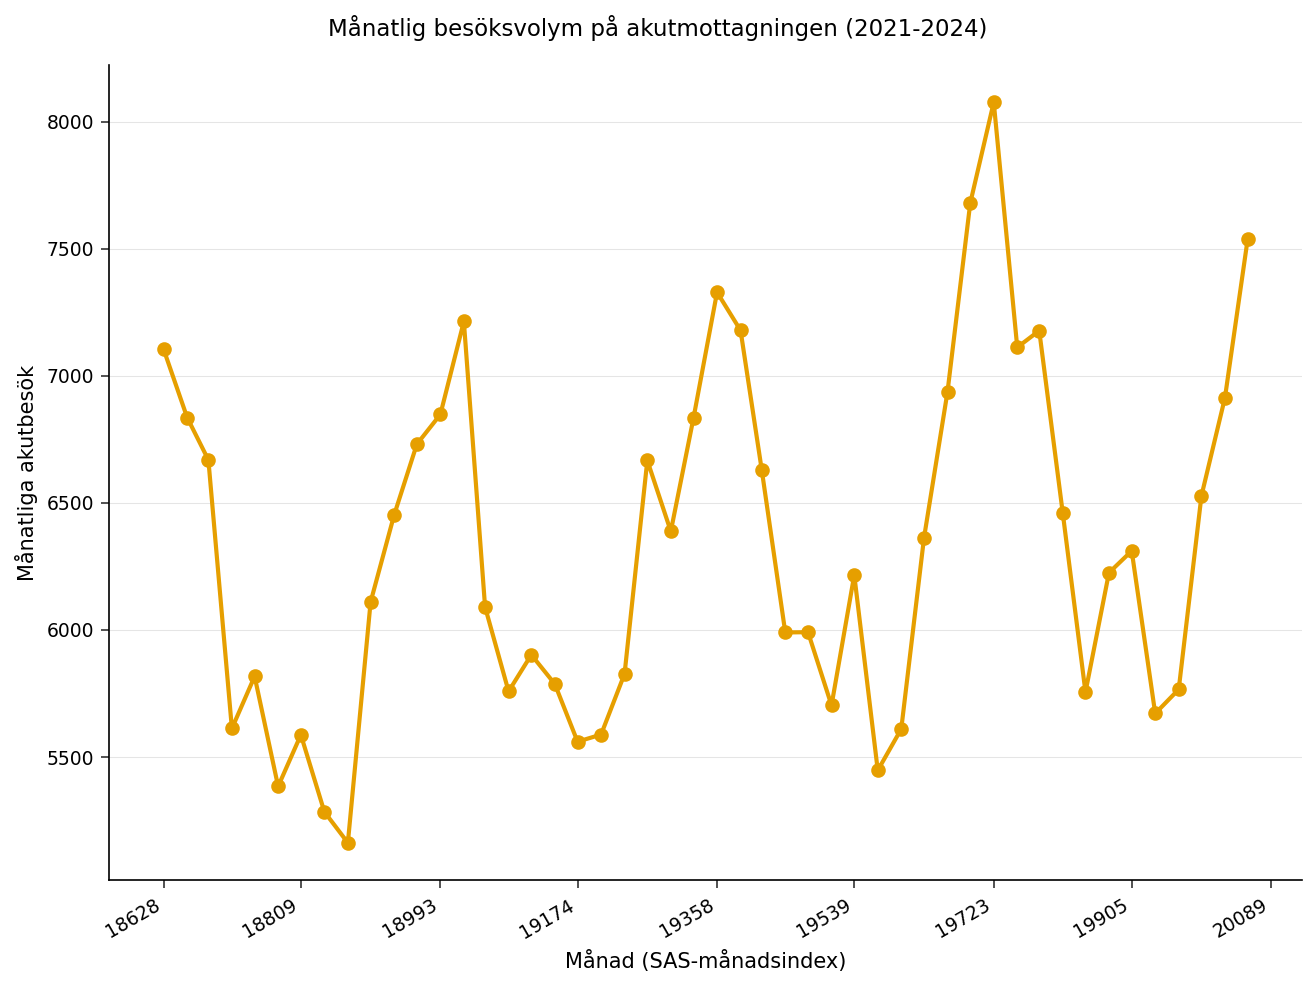

In [2]:
PROCEDUR SGPLOT data=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS ETIKETT="Månad (SAS-månadsindex)";
    YAXIS ETIKETT="Månatliga akutbesök" grid;
    TITEL "Månatlig besöksvolym på akutmottagningen (2021-2024)";
KÖR;


Plotten visar fyra tydliga årliga cykler. Varje vintertopp ligger en aning högre än den föregående, och stiger från ungefär 7 100 år 2021 till cirka 8 100 vid toppen 2024, medan sommardalarna stiger mer blygsamt - säsongssvängningen växer med nivån. Den breddande amplituden är kännetecknet för multiplikativ säsongsvariation och motiverar `MODEL=WINTERS` (multiplikativ Winters) i nästa steg.


## Steg 3 - Anpassa den multiplikativa Winters-modellen

Vi anpassar multiplikativ Winters-säsongsutjämning på hela den 48 månader långa historiken. `ID`-satsen deklarerar `month` som tidsindex med intervallet `MONTH`, och `FORECAST`-satsen begär `MODEL=WINTERS` med `LEAD=12` för att projicera ett år framåt. Vi fångar tre utdataset:

- `OUT=` - den historiska serien med prognosen tillagd (en `ed_visits`-kolumn), med tidsindexet utsträckt över prognoshorisonten - idealisk för plottning.
- `OUTFOR=` - prognoskomponenterna per period: punktprognos (`PREDICT`) och de nedre/övre prediktionsgränserna.
- `OUTSUM=` - modellens anpassningsstatistik (RMSE, MAE, MAPE, AIC) och utjämningsvikter, i en enda sammanfattande rad.

`ALPHA=0.05` ger 95 % prediktionsgränser, lämpligt för riskmarginaler i kapacitetsplaneringen. `PRINT=(STATISTICS)` ekar anpassningsstatistiken och utjämningsvikterna till utskriften.


In [3]:
PROCEDUR esm data=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        SKRIV=(statistics);
    id month interval=month;
    forecast ed_visits / MODEL=winters ALPHA=0.05;
KÖR;

PROCEDUR SKRIV data=esm_summary noobs ETIKETT;
    ETIKETT rmse="RMSE" mae="MAE" mape="MAPE"
          ALPHA="Nivå (alfa)" beta="Trend (beta)" gamma="Säsong (gamma)";
    VARIABEL rmse mae mape ALPHA beta gamma;
    TITEL "Winters anpassningsstatistik och utjämningsvikter";
KÖR;


                                    Första 14 månaderna av syntetisk akutbesöksvolym                                    


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                   Winters anpassningsstatistik och utjämningsvikter                                    

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


`OUTSUM=`-raden och den utskrivna statistiken överensstämmer: den multiplikativa Winters-anpassningen uppnår en **RMSE inom stickprovet på 320,4 besök**, **MAE på 264,4** och **MAPE på 4,16 %** - ett typiskt månatligt fel bekvämt under 5 % av volymen, vilket är tillräckligt exakt för bemanningsplanering. Utjämningsvikterna är **alpha = 0,30** (nivå), **beta = 0,10** (trend) och **gamma = 0,10** (säsong). Den måttliga nivåvikten låter grundnivån driva uppåt med patientpopulationens tillväxt, medan de små trend- och säsongsvikterna återspeglar att tillväxttakten och vintertoppens form är stabila år för år och inte bör överreageras på från månad till månad.

> Obs: detta är anpassningsstatistik *inom stickprovet* beräknad över estimeringsurvalet, inte ett urval utanför stickprovet (holdout). Den kvantifierar hur nära modellen följer den historik den anpassats på.


## Steg 4 - Sammanställ och tabellera 12-månadersprognosen

`OUTFOR=`-datasetet innehåller punktprognosen och prediktionsgränserna för varje period, medan `OUT=`-datasetet bär tidsindexet rent utsträckt över prognoshorisonten. Vi anpassar de två efter observationsordning för att koppla prognosdatumen till prediktionsgränserna, och behåller sedan bara de 12 prognosmånaderna. Detta är siffrorna som en bemanningskommitté skulle agera på.


In [4]:
/* OUT= carries the forecast-horizon dates; OUTFOR= carries the
   prediction limits. Align them by observation order to put dates on
   the limits, then keep only the 12 forecast months.            */
data out_idx;
    STÄLL_IN ed_with_forecast;
    row = _n_;
    BYT_NAMN month = fdate ed_visits = series_value;
KÖR;

data for_idx;
    STÄLL_IN esm_forecast;
    row = _n_;
    BYT_NAMN ed_visits = observed;
    BEHÅLL row observed predict LOWER UPPER;
KÖR;

data forecast_path;
    SAMMANFOGA out_idx for_idx;
    EFTER row;
    format fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
KÖR;

data forecast_horizon;
    STÄLL_IN forecast_path;
    DÄR observed = .;   /* forecast months only (no observed value) */
    BEHÅLL fdate predict LOWER UPPER;
KÖR;

PROCEDUR SKRIV data=forecast_horizon noobs ETIKETT;
    ETIKETT fdate   = "Månad"
          predict = "Prognostiserade besök"
          LOWER   = "95% nedre"
          UPPER   = "95% övre";
    TITEL "12-månaders prognos för akutbesök med 95% prediktionsgränser";
KÖR;


                              12-månaders prognos för akutbesök med 95% prediktionsgränser                              

 Månad   Prognostiserade besök  95% nedre   95% övre
202501                   7,822      7,194      8,450
202502                   7,539      6,651      8,427
202503                   7,292      6,204      8,380
202504                   6,263      5,007      7,519
202505                   6,397      4,992      7,801
202506                   6,039      4,501      7,578
202507                   6,236      4,574      7,897
202508                   5,867      4,091      7,644
202509                   5,802      3,918      7,686
202510                   6,804      4,818      8,790
202511                   7,173      5,090      9,256
202512                   7,567      5,391      9,742




NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


Prognosen för säsongssignaturen vidare in i 2025. Modellen projicerar toppen i januari 2025 till cirka **7 822 besök** (95 %-intervall 7 194-8 450), avtar genom våren, bottnar i sensommardalen nära **5 802** i september (intervall 3 918-7 686) och bygger sedan upp sig till en decembertopp på ungefär **7 567** (intervall 5 391-9 742). Prediktionsbandet breddas stadigt med horisonten - nästa månads intervall spänner cirka +/-630 besök, medan nästa decembers spänner mer än +/-2 000 - en direkt påminnelse om att planer på kort sikt är betydligt fastare än de vid årets slut.


## Steg 5 - Plotta historik plus prognos

Slutligen, lägg prognosen ovanpå den observerade historiken så att planerare kan se den projicerade vintertoppen och det breddande osäkerhetsbandet i takt med att horisonten sträcks ut. Vi delar upp den anpassade `forecast_path`-serien i den **observerade** historiken (heldragen) och den **12-månaders prognosen** (streckad) så att övergången blir tydlig, och ritar 95 %-prediktionsbandet under. X-axeln är det månatliga SAS-datumindexet, som löper från vänster till höger från jan 2021 till dec 2025.


                              12-månaders prognos för akutbesök med 95% prediktionsgränser                              




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


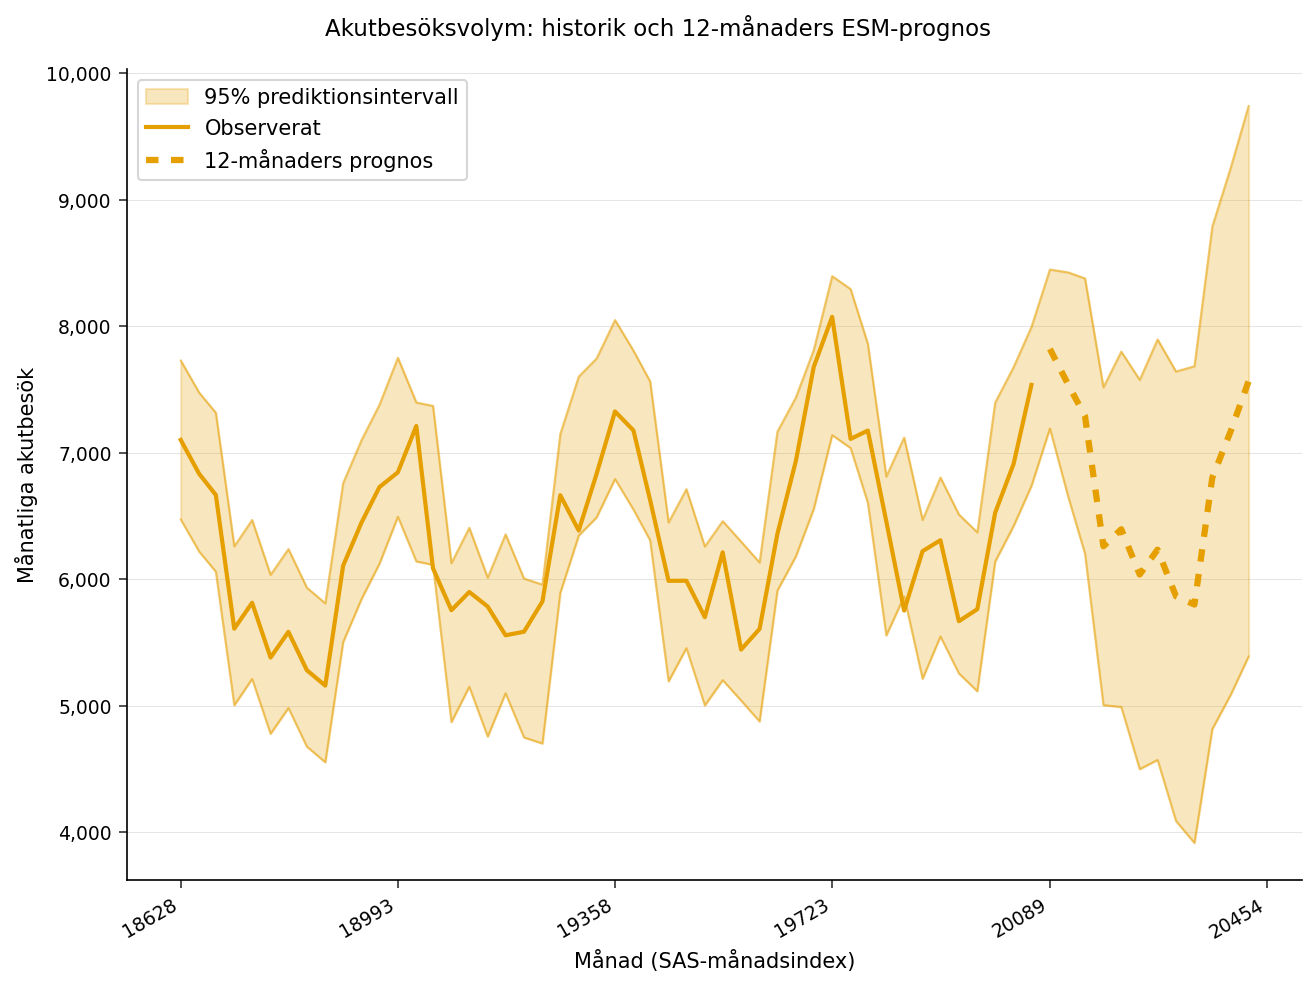

In [5]:
/* Split the projected series into the observed history and the
   12-month forecast so they render with distinct styling, and overlay
   the 95% prediction band from the aligned forecast_path dataset.   */
data forecast_plot;
    STÄLL_IN forecast_path;
    OM observed = . SÅ fc_only = predict;   /* future months only */
    ANNARS fc_only = .;
KÖR;

PROCEDUR SGPLOT data=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel="95% prediktionsintervall" TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel="Observerat";
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel="12-månaders prognos";
    XAXIS ETIKETT="Månad (SAS-månadsindex)";
    YAXIS ETIKETT="Månatliga akutbesök" grid;
    TITEL "Akutbesöksvolym: historik och 12-månaders ESM-prognos";
KÖR;


## Tolkning av resultaten

Den multiplikativa Winters-modellen bryter ner ED-volymen i en långsamt stigande **nivå**, en nästan platt **trend** och ett stabilt **säsongsmönster**. Utjämningsvikterna avlästa från `OUTSUM=` berättar historien: en måttlig nivåvikt (alpha = 0,30) låter grundnivån driva uppåt med patientpopulationens tillväxt, medan små trend- och säsongsvikter (beta = gamma = 0,10) återspeglar att tillväxttakten och vintertoppens form är mycket stabila år för år och inte bör överreageras på från månad till månad.

**Anpassningsstatistiken** bekräftar att modellen följer historiken väl: en RMSE på cirka 320 besök och en MAPE på 4,16 % innebär att det typiska månatliga felet ligger under 5 % av volymen. Operativt sett kvantifierar **prognostabellen och bandplotten** toppen i december-februari som akutmottagningen bör bemanna mot - ungefär 7 300-7 800 besök under vintermånaderna - och 95 %-prediktionsgränserna definierar ett förnuftigt kapacitetsintervall: planera kärnbemanningen mot punktprognosen, och förbered i förväg flextäckning och surge-sängar mot den övre gränsen. Intervallet breddas med horisonten, så nästa månads plan är betydligt fastare än nästa decembers och bör uppdateras när nya utfall kommer in.

**Utvidgningar:** jämför `MODEL=ADDWINTERS` (additiv säsongsvariation) mot den multiplikativa anpassningen för att bekräfta det multiplikativa valet; tillämpa `TRANSFORM=LOG` för att framtvinga positivitet och stabilisera variansen; eller lägg till en `BY`-sats för att prognostisera flera sjukhusenheter i ett enda PROC ESM-anrop.
